In [2]:
import stack_tools
import importlib

In [3]:
from scipy.special import erf
from scipy.optimize import curve_fit
from scipy.stats import lognorm,norm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np
from scipy.special import erfc, erfcx, log_ndtr
%matplotlib ipympl


In [4]:
no_marg = stack_tools._log_likelihood_ul(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))
marg = stack_tools._log_likelihood_ul_nuisance(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))

/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:157: RuntimeWarning: divide by zero encountered in log
  prior_vs_sigma = np.log(sigma_e[None,:] * ((sigma_data**2 + sigma_model**2)[:,None] + sigma_e[None,:]**2)**-1) # shape: (n_bursts, n_sigma_e)


In [5]:
%pdb on

Automatic pdb calling has been turned ON


In [194]:
def lognormal_from_moments(x,mean, std):
    """
    Given mean and variance moments, return a log-normal PDF with matching moments.
    
    For a log-normal distribution, if X ~ LogNormal(μ, σ²), then:
    - E[X] = exp(μ + σ²/2)
    - Var[X] = exp(2μ + σ²) * (exp(σ²) - 1)
    
    Solving for μ and σ:
    - σ² = ln(1 + variance/mean²)
    - μ = ln(mean) - σ²/2
    
    Parameters:
    -----------
    mean : float
        The desired mean of the distribution (must be positive)
    variance : float
        The desired variance of the distribution (must be positive)
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'mu': μ parameter of the log-normal distribution
        - 'sigma': σ parameter of the log-normal distribution
        - 'pdf': function that evaluates the PDF at given points
        - 'scipy_dist': scipy.stats lognorm object for additional methods
    
    Raises:
    -------
    ValueError: If mean or variance are not positive
    """
    
    if mean <= 0:
        raise ValueError("Mean must be positive for log-normal distribution")
    if std <= 0:
        raise ValueError("Variance must be positive")

    variance = std**2
    # Calculate log-normal parameters from moments
    sigma_squared = np.log(1 + variance / (mean**2))
    sigma = np.sqrt(sigma_squared)
    mu = np.log(mean) - sigma_squared / 2
    return lognormal_from_musigma(x, mu, sigma)

def lognormal_from_musigma(x, mu, sigma, floor = -100):
    """Get logpdf"""
    scipy_dist = lognorm(s=sigma, scale=np.exp(mu))
    ans = scipy_dist.logpdf(x)
    return np.exp(np.maximum(ans,np.max(ans) + floor))
    
def gaussian_from_moments(x, mean, std,floor = -100):
    """Get logpdf"""
    scipy_dist = norm(loc = mean,scale = std)
    ans = scipy_dist.logpdf(x)
    return np.exp(np.maximum(ans,np.max(ans) + floor))
    


def get_dm_dist(x,mu,sigma,dist='gauss',moments = 'real'):
    if dist == 'gauss' and moments == 'real':
        return gaussian_from_moments(x,mu,sigma)
    if dist == 'logn' and moments == 'real':
        return lognormal_from_moments(x,mu,sigma)
    if dist == 'logn' and moments == 'log':
        return lognormal_from_musigma(x,mu,sigma)
    else:
        print(dist,moments)
        
from scipy.interpolate import CubicSpline

def norm_ll(ll):
    return ll - np.nanmax(ll)
    
def log_likelihood_hp(df,res,weight_index = 2,verbose = False,sigma_cbm_arr = np.linspace(1,100,num = 10),
                                dm_cbm_arr = np.linspace(1,200, num = 30),dist = ['gauss','gauss','gauss']):
    """Computes log likelihood with proper treatment of the hyperparameters (hence, 'hp' in the name).

    Returns an array whose shape is the same as ms."""
    msb = np.array(res['M_star_bins'])
    bin_centers = np.sqrt(msb[:,0] * msb[:,1])
    indices = np.zeros(len(df),dtype = int)
    for ii,_ms in enumerate(df['published_M*']):
        indices[ii] = np.argmin(np.abs(bin_centers - _ms))
    if dist[1] == 'gauss': # moment match
        print('Real moments')
        model = res['weighted_mean'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
        model_err = res['weighted_std'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
        cgm_moments = 'real'
    # lognormal moments
    if dist[1] == 'logn':
        print('Using moments measured directly')
        model = res['logn_mu'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
        model_err = res['logn_sigma'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
        cgm_moments = 'log'
    dm_host_restframe = df['DM_host_restframe']
    sigma_cosmic = dmh_tools.sigma_igm_walker2024(df['primary_z_spec'])
    dm_model = np.array(model)
    dm_model_err = np.array(model_err)
    ll_per_burst_logn = np.zeros((len(df),len(sigma_cbm_arr),len(dm_cbm_arr)))
    
    for ii in range(len(df)):
        x_vals = np.linspace(0,dm_host_restframe[ii] * 5,num = 500,endpoint = False)
        _ll = ll_convolved(x_vals,
                         mu1 = 0, 
                         sd1 = sigma_cosmic[ii],
                         mu2 = dm_model[ii],
                         sd2 = dm_model_err[ii], 
                         mu3 = dm_cbm_arr, 
                         sd3 = sigma_cbm_arr,
                        moments = ['real',cgm_moments,'real'],
                        dist = dist)
        ll_per_burst_logn[ii] = _ll[...,100]
        if verbose:
            ii_dmcbm = np.argmin(np.abs(dm_cbm_arr - 56))
            jj_sigmacbm = np.argmin(np.abs(dm_cbm_arr - 100))
            plt.figure(ii)
            plt.plot(x_vals,_ll[jj_sigmacbm,ii_dmcbm,:],label = res['filepath'].split('/')[-1])
            plt.axvline(dm_host_restframe[ii])
            plt.ylim(-10,0)
            plt.title(df.index[ii],)
            plt.legend()
        
    return ll_per_burst_logn


In [195]:
def ll_convolved(x,mu1,sd1,mu2,sd2,mu3,sd3,num = 1000,moments = ['real','log','real'],dist = ['gauss','logn','logn'],verbose = False):
    """Numerical likelihood = posteriorVectorized over mu3, sd3. 

    1 -> DM_cosmic
    2 -> DM_cgm
    3 -> DM_cbm
    
    mu1 : float
        A location parameter for the first variable.
        
    sd1 : float
        A width parameter for the first variable. 

    moments : list of length 3
        If 'real', then the parameters will interpreted as the mean and st. dev. of the DM and moment-matched to a log-normal distribution.
        If 'log', then the parameters will be interpreted as the mu and sigma of the log-normal distribution of the DM.
    """
    x = np.atleast_1d(x)
    xrange = (mu1 + mu2 + np.max(np.abs(mu3)) + sd1 + sd2 + np.max(np.abs(sd3))) * 2
    common_grid = np.linspace(-xrange,xrange,num = num)
    dx = common_grid[1]-common_grid[0]
    p1 = get_dm_dist(common_grid,mu1,sd1,moments = moments[0],dist = dist[0])
    p2 = get_dm_dist(common_grid,mu2,sd2,moments = moments[1],dist = dist[1])
    p12 = np.convolve(p1 / np.max(p1),p2 / np.max(p2),mode = 'same') * np.max(p1) * np.max(p2)
    mu3 = np.atleast_1d(mu3)
    sd3 = np.atleast_1d(sd3)
    ans = np.zeros((sd3.size,mu3.size,x.size))
    p123 = np.zeros_like(p1)
    for iimu3,_mu3 in enumerate(mu3):
        for iisd3,_sd3 in enumerate(sd3):
            p3 = get_dm_dist(common_grid,_mu3,_sd3,moments = moments[2],dist = dist[2])
            p123 += np.convolve(p12 / np.max(p12) ,p3 / np.max(p3),mode = 'same') * np.max(p12) * np.max(p3) 
            if np.isfinite(p123).all():
                p123 /= np.sum(p123 * dx) # normalize the likelihood such that it is also a valid posterior as a function of DM_eg
                spl = CubicSpline(common_grid, np.log(p123 + 1e-100))
                out = spl(x)
            else:
                print(f'WARNING: for mu={_mu3},sigma={_sd3}, no probability mass! Setting posterior to 0 here')
                out = 0
                
            ans[iisd3,iimu3,:] = out
            
            if verbose:
                plt.figure()
                plt.plot(common_grid,p1,label = 'p1')
                plt.plot(common_grid,p2,label = 'p2')
                plt.plot(common_grid,p3,label = 'p3')
                plt.plot(common_grid,p12,label = 'p12')
                plt.plot(common_grid,p123,label = 'p123')
                plt.title('debug')
                plt.legend()
                plt.yscale('log')
            
    return ans.squeeze()

In [196]:

import pandas as pd
import dmh_tools,camels_tools
import os

models = ['Astrid','IllustrisTNG','SIMBA']
variants = [
    ['Apples (z=0.1)',('086',0.13,0.20,2,'same_sigmacgm')],
    #['Fiducial (z=0.1)',('086',0.13,0.20,2,'fid0.1')],
    #['Fiducial (z=0.0)',('090',0.13,0.20,2,'fid0')],
    #['Fiducial (z=0.2)',('082',0.13,0.20,2,'fid0.2')],
    #[r'$0.10 < b < 0.20$',('086',0.1,0.2,2,'lowb')],
    #[r'$0.10 < b < 0.16$',('086',0.1,0.16,2,'highb')],
    #[r'P(O|x) > 0.95',('086', 0.13, 0.20,2,'goldgold')],
    #[r'Weighting $\propto M^*$',('086',0.13,0.2,1)],
    #[r'Weighting $\propto SFR \times M^*$',('086',0.13,0.2,3)],
    #['Uniform weight' ,('086',0.13,0.20,0)],
    #[r'$\langle DM_{cosmic} \rangle$ +50%',('086',0.13,0.20,2,'high_igm')],
    #[r'$\langle DM_{cosmic} \rangle$ -50%',('086',0.13,0.20,2,'low_igm')],
    #[r'1.5 $\times\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'inflate_sigma_cosmic')],
    #[r'Varying $\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'varying_sigma_cosmic')],
    #[r'Low end only ($M^* < 10^{9.8}$)',('086', 0.13, 0.20,2,'low')],
    #[r'High end only ($M^* > 10^{9.8}$)',('086', 0.13, 0.20,2,'high')],
    #[r'All $M^*$ -0.3 dex',('086', 0.13, 0.20,2,'low_mstar')],
    #[r'Knockout',('086', 0.13, 0.20,2,'knockout')],
    #[r'Zero model',('086', 0.13, 0.20,2,'null_model')],
    #[r'No data',('086', 0.13, 0.20,2,'no_data')],
]
ROOT_PATH = os.getcwd() + '/../'


In [197]:
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
num_good_bursts = np.sum(keep)

In [198]:
import importlib
importlib.reload(stack_tools)

<module 'stack_tools' from '/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py'>

In [199]:
plt.close('all')

# Do calculation

In [200]:
plt.close('all')

Astrid Apples (z=0.1)
Using moments measured directly


/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_31700/2438088963.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_vals = np.linspace(0,dm_host_restframe[ii] * 5,num = 500,endpoint = False)
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_31700/2438088963.py:118: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axvline(dm_host_restframe[ii])


IllustrisTNG Apples (z=0.1)
Using moments measured directly
SIMBA Apples (z=0.1)
Using moments measured directly


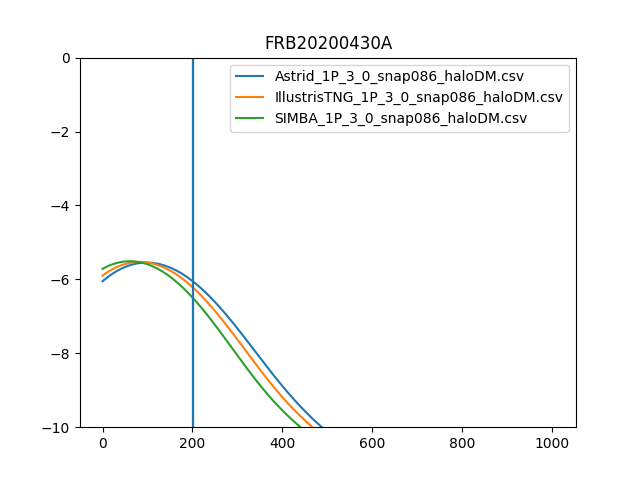

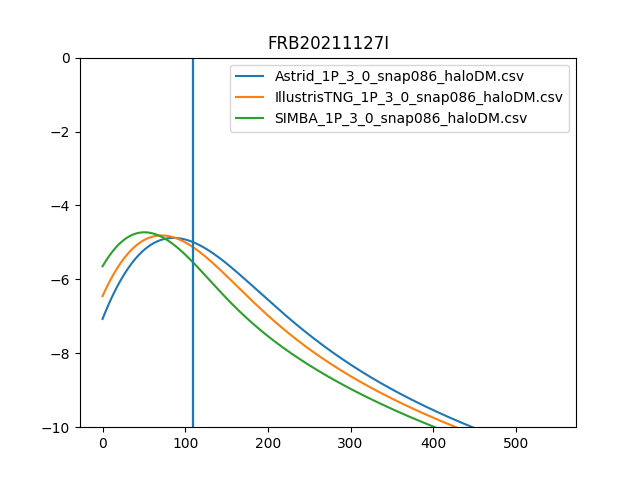

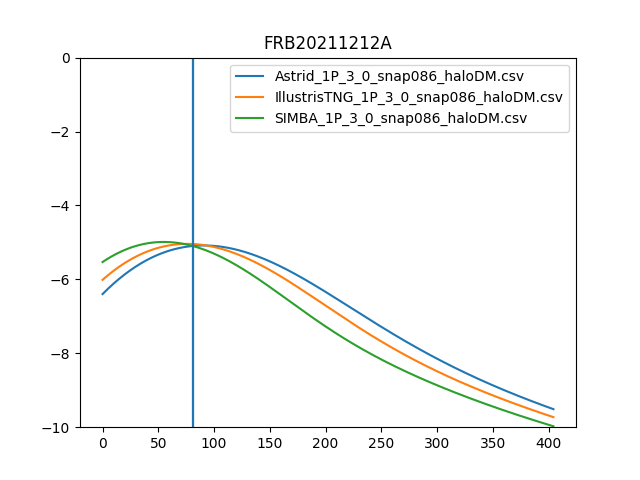

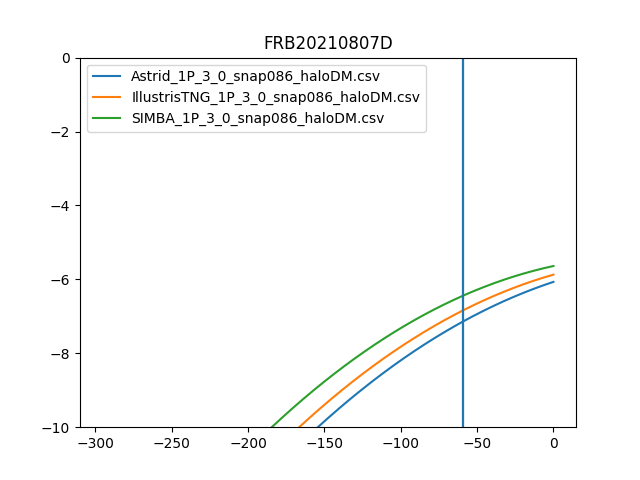

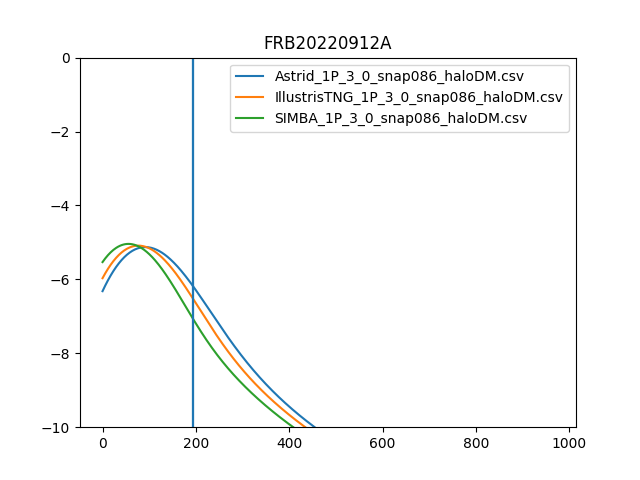

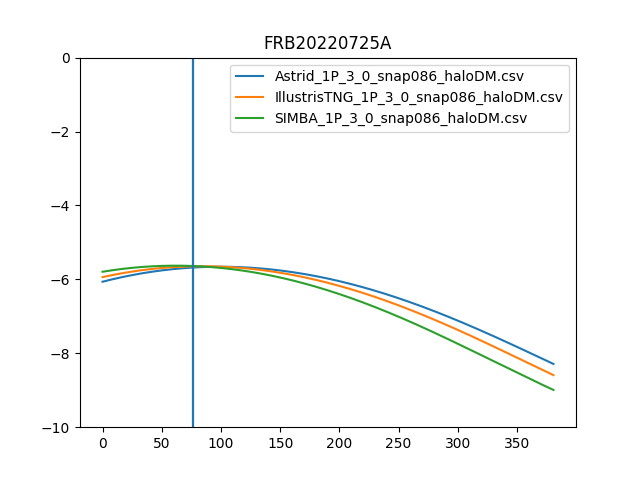

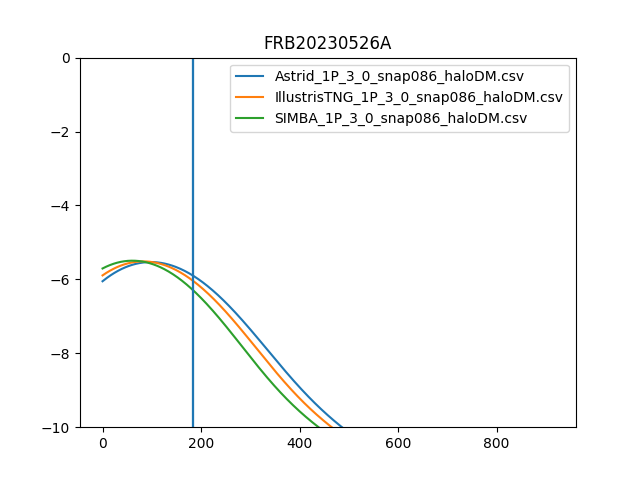

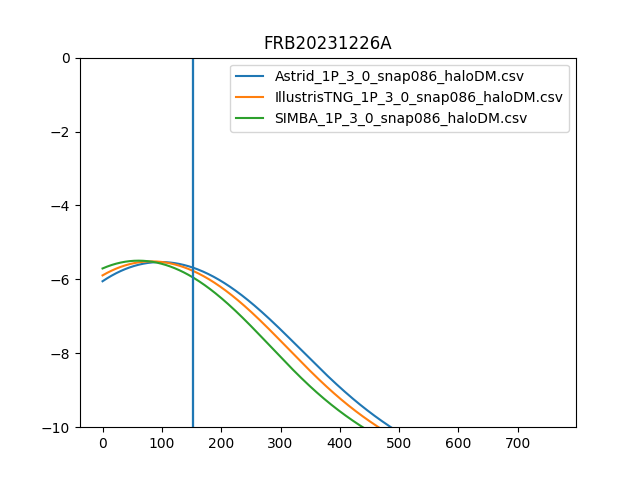

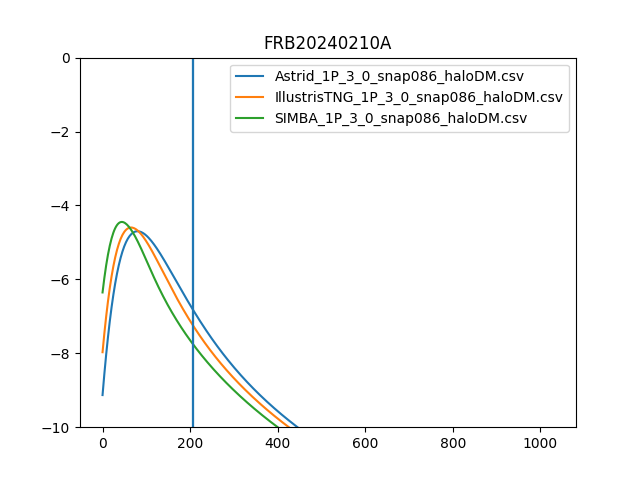

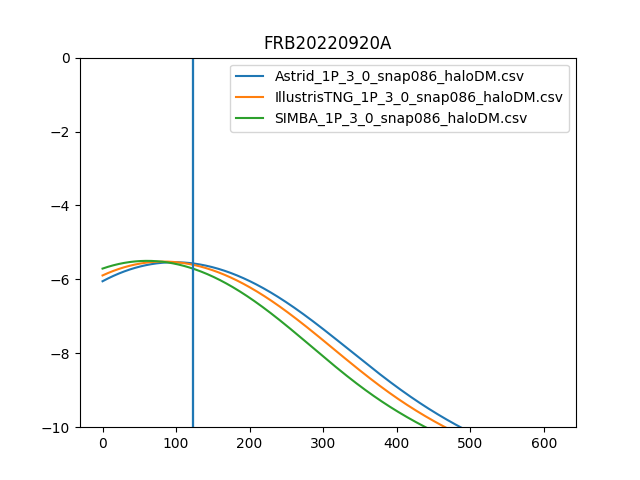

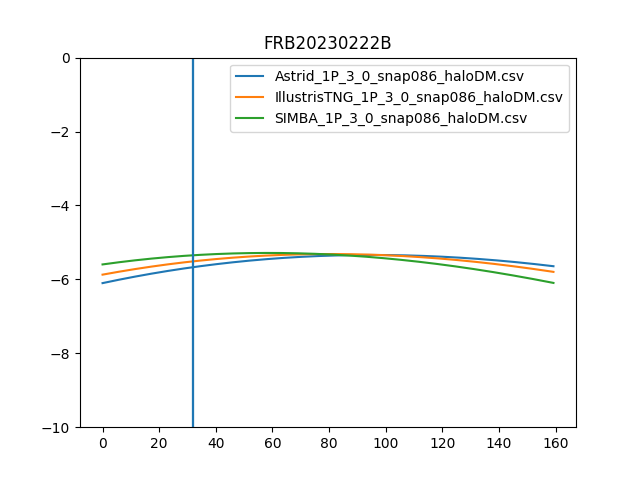

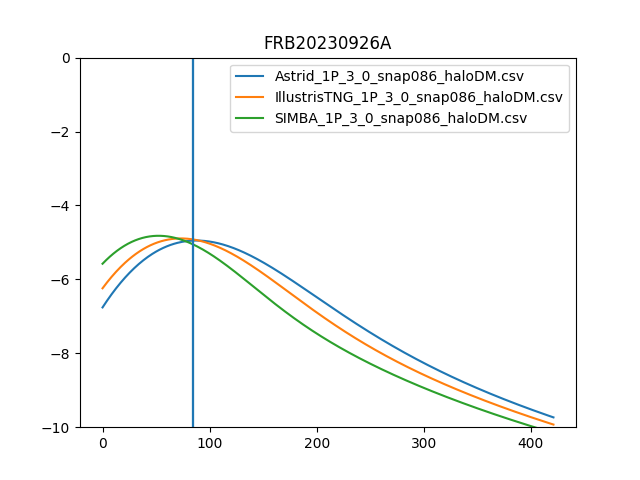

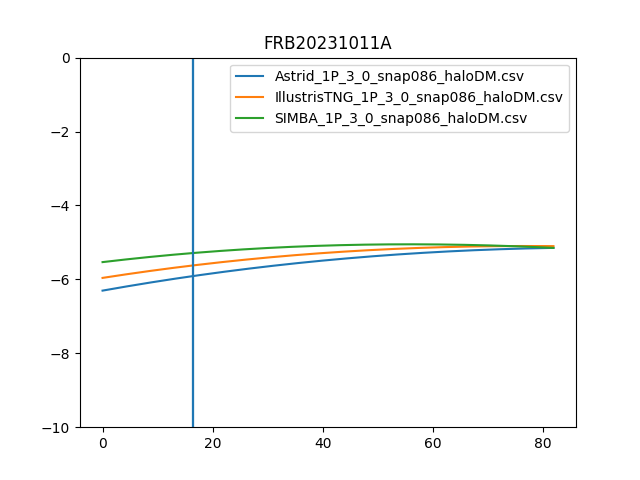

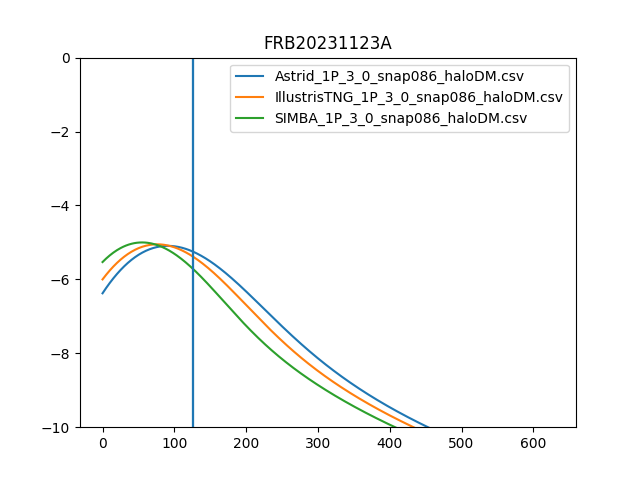

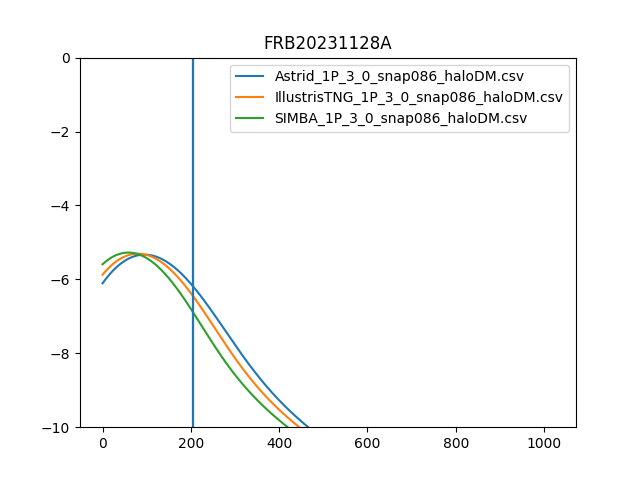

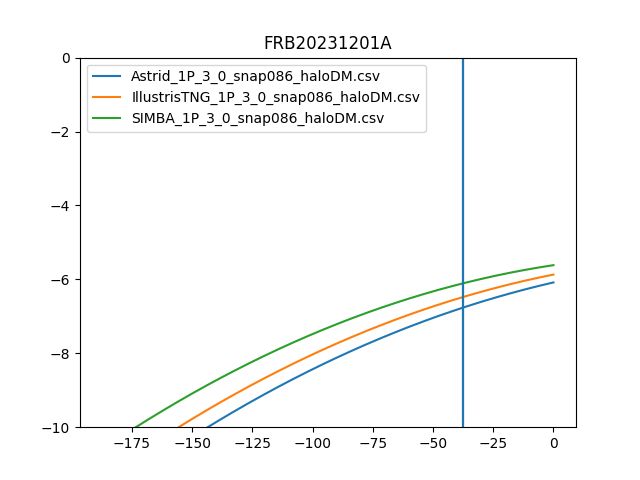

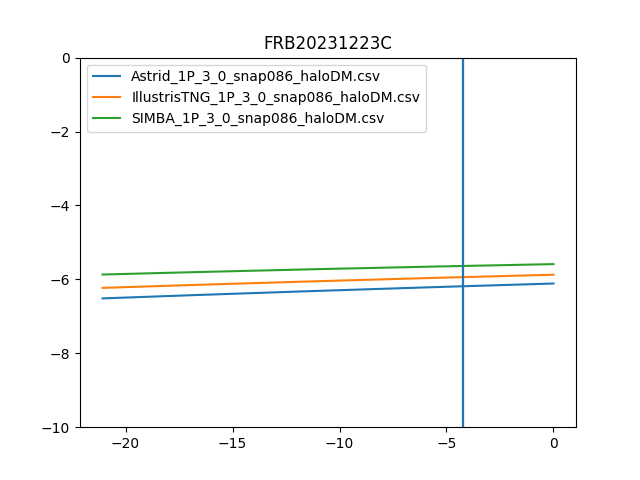

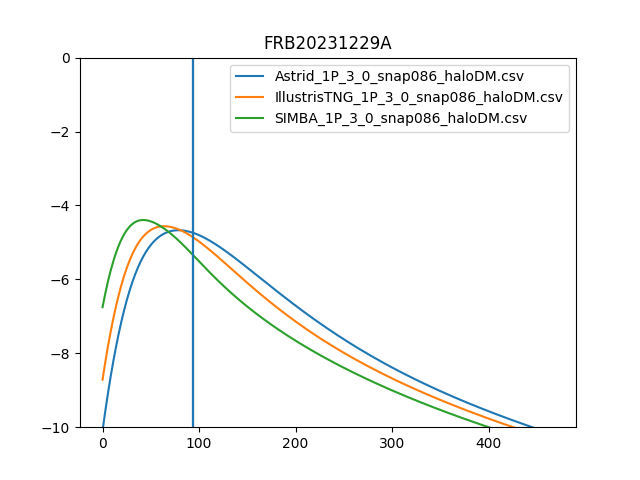

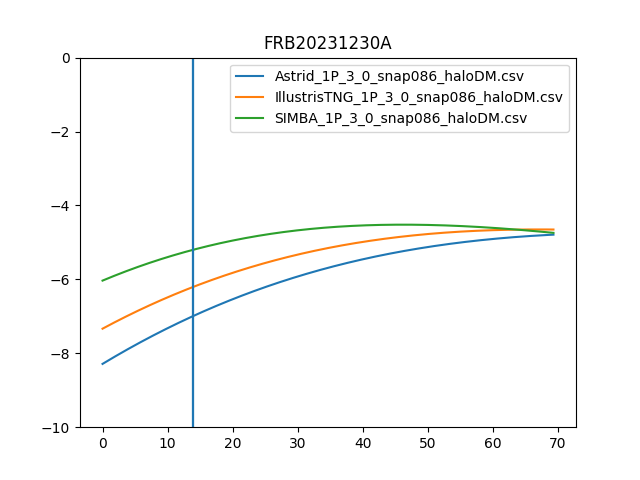

In [201]:

sigma_cbm_arr = np.linspace(10,200,num = 24)  #np.linspace(1,100,num = 1)
dm_cbm_arr = np.linspace(1,200,num = 20) #np.linspace(0,200, num = 1)
prior = np.log(1/sigma_cbm_arr[:,None] + np.zeros_like(dm_cbm_arr)[None,:])
ll_per_variant_model_burst = np.zeros((len(variants),3,num_good_bursts,len(sigma_cbm_arr),len(dm_cbm_arr)))
ll_per_variant_model_test = np.zeros((len(variants),3,num_good_bursts,len(sigma_cbm_arr),len(dm_cbm_arr)))

ll_per_variant = np.zeros((3,len(variants)))
import importlib

for iivariant,(variant_name,params) in enumerate(variants):
    _df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
    _df.set_index('name',inplace=True)
    keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
    df = _df[keep]
    plot_mstar = df['published_M*']
    plot_dm = df['DM_host_restframe']
    plot_dmerr = dmh_tools.sigma_tot(df)
    for iimodel,model in enumerate(models):
        keep = dmh_tools.not_low_dm(df) * dmh_tools.not_scattered(df) * dmh_tools.not_clusters(df) * dmh_tools.not_edge_on(df) * dmh_tools.not_dwarf(df) * dmh_tools.not_elliptical(df) 
        # analysis perturbations
        vary_igm_factor = 0
        model_mult = 1
        model_err_mult = 1
        model_err_offset = 0
        data_err_mult = 1
        mstar_bias_dex = 0.0    
        try:
            (snap_id, b_min, b_max, iiweight,variant) = params
        except:
            (snap_id, b_min, b_max, iiweight) = params
        if variant == 'same_sigmacgm':
            model_err_mult = 0
            model_err_offset = 1 # take a scatter of 70 pc cm-3
        if variant == 'low':
            keep = df['published_M*'] < 9.8
        elif variant == 'high':
            keep = df['published_M*'] >= 9.8
        elif variant == 'low_igm':
            vary_igm_factor = -0.5
        elif variant == 'high_igm':
            vary_igm_factor = 0.5
        elif variant == 'goldgold':
            keep = keep * np.isnan(df['primary_P_Ox']) + (df['primary_P_Ox'] > 0.95)
        elif variant == 'null_model':
            model_mult = 0
        elif variant == 'varying_sigma_cosmic':
            if model == 'SIMBA':
                data_err_mult = 0.8
            if model == 'Astrid':
                data_err_mult = 1.5
            if model == 'IllustrisTNG':
                data_err_mult = 1.0
        elif variant == 'inflate_sigma_cosmic':
            data_err_mult = 1.5
        elif variant == 'low_mstar': # if we overestimate our stellar masses
            mstar_bias_dex = -0.3
        elif variant == 'no_data':
            data_err_mult = 100
        redshift_str = f"z = {camels_tools.CAMELS_REDSHIFTS[snap_id]:.2f}"
        snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
        stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM' + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5'
        results = camels_tools.from_file(stack_path)
        results['weighted_mean'] *= model_mult
        results['weighted_mean'] *= model_mult
        results['weighted_std'] *= model_err_mult
        results['weighted_std'] += model_err_offset
        if 0: # old code
            ll_per_variant_model_burst[iivariant,iimodel,keep] = stack_tools.log_likelihood_hp_gauss(
                ms = (plot_mstar * 10**(mstar_bias_dex))[keep],
                dm = ((plot_dm + vary_igm_factor * df['dm_igm']))[keep],
                dm_err = ((plot_dmerr * data_err_mult))[keep],
                res=results,
                sigma_cbm_arr = sigma_cbm_arr,
                dm_cbm_arr = dm_cbm_arr,
                weight_index = iiweight)
        if 0: # general code
            ll_per_variant_model_test[iivariant,iimodel,keep] = log_likelihood_hp(
                df[keep],
                res = results,
                weight_index = 2,
                verbose = True,sigma_cbm_arr = sigma_cbm_arr,
                                dm_cbm_arr = dm_cbm_arr,dist = ['gauss','logn','logn'])
        if 1: # general code
            print(model,variant_name)
            ll_per_variant_model_burst[iivariant,iimodel,keep] = log_likelihood_hp(
                df[keep],
                res = results,
                weight_index = 2,
                verbose = True,sigma_cbm_arr = sigma_cbm_arr,
                                dm_cbm_arr = dm_cbm_arr,dist = ['gauss','logn','logn'],)


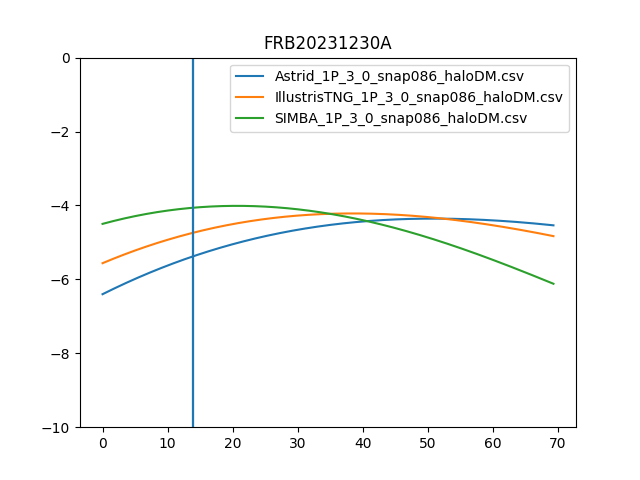

In [193]:
plt.show()

In [185]:
df.loc['FRB20200430A']['DM_host_restframe'] / (1 +df.loc['FRB20200430A']['primary_z_spec'] *0)

np.float64(201.0597051296631)

In [162]:
plt.close('all')

/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_31700/3835847752.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (15,4))


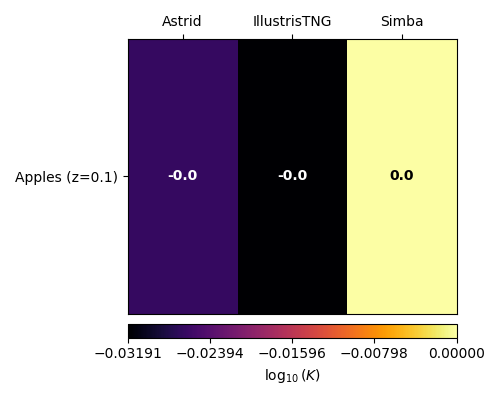

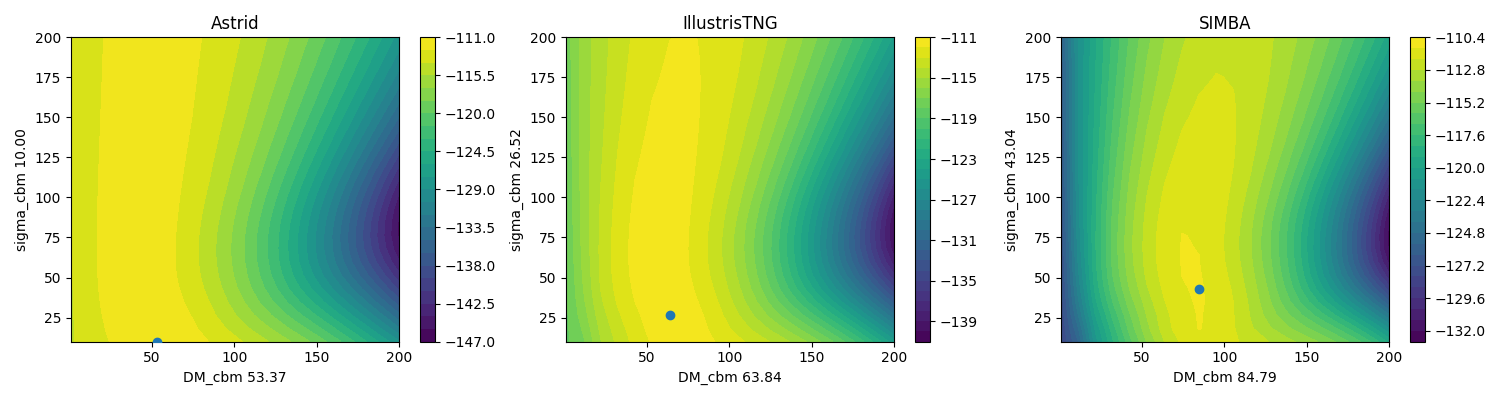

In [202]:
prior = (dm_cbm_arr > 0)[None,:] + (1/sigma_cbm_arr)[:,None]

def make_ll_plots(grid,dm_cbm_arr, sigma_cbm_arr,prior, iivariant = 0):
    _ll = grid
    _ll[np.isnan(_ll)] = -np.inf
    for iivariant,(variant_name,params) in enumerate(variants):
        ll_per_variant[:,iivariant] = stack_tools.marginalize_ll_hp(
                                            _ll[iivariant],
                                            prior,
                                            dm_cbm_arr,
                                            sigma_cbm_arr,
                                        )
    fig = plt.figure(figsize = (5,4))
    #plt.title(r'Bayes')
    stack_tools.plot_fig2(fig,plt.gca(),ll_per_variant * np.log10(np.e), cmap = 'inferno',xnames = ['Astrid','IllustrisTNG','Simba'], 
        ynames = np.array([v[0] for v in variants]), cbar_label = r'$\log_{10}(K)$',
    )
    plt.tight_layout()
    
    def find_argmax(x,y,xy):
        shape = xy.shape
        iy,ix = np.unravel_index(np.argmax(xy.flat),shape)
        return x[ix],y[iy]
    plt.figure(figsize = (15,4))

    for iimodel,model in enumerate(models):
        plt.subplot(130+iimodel+1)
        plt.title(model)
        ans = np.log(prior) + np.sum(_ll,axis = 2)[iivariant,iimodel]
        x,y = find_argmax(dm_cbm_arr,sigma_cbm_arr,ans)
        plt.scatter(x,y,zorder = 10)

        plt.contourf(dm_cbm_arr,sigma_cbm_arr,ans,levels = 30)
        plt.xlabel(f'DM_cbm {x:.2f}')
        plt.ylabel(f'sigma_cbm {y:.2f}')
        plt.colorbar()
        plt.tight_layout()
    return
make_ll_plots(ll_per_variant_model_burst, dm_cbm_arr, sigma_cbm_arr, prior,iivariant = 0)

array([-89.82168659, -88.66835483, -87.52260348, -86.38443246,
       -85.25384167, -84.13083102, -83.01540043, -81.90754981,
       -80.80727906, -79.71458809, -78.62947682, -77.55194515,
       -76.48199301, -75.41962028, -74.36482689, -73.31761275,
       -72.27797777, -71.24592185, -70.22144491, -69.20454686,
       -68.1952276 , -67.19348705, -66.19932512, -65.21274172,
       -64.23373676, -63.26231014, -62.29846179, -61.3421916 ,
       -60.39349949, -59.45238537, -58.51884915, -57.59289075,
       -56.67451006, -55.763707  , -54.86048148, -53.96483341,
       -53.07676271, -52.19626927, -51.32335302, -50.45801386,
       -49.6002517 , -48.75006645, -47.90745802, -47.07242633,
       -46.24497128, -45.42509278, -44.61279075, -43.80806509,
       -43.01091571, -42.22134253, -41.43934545, -40.66492438,
       -39.89807924, -39.13880994, -38.38711637, -37.64299848,
       -36.90645622, -36.17748955, -35.45609846, -34.74228294,
       -34.036043  , -33.33737863, -32.64628982, -31.96

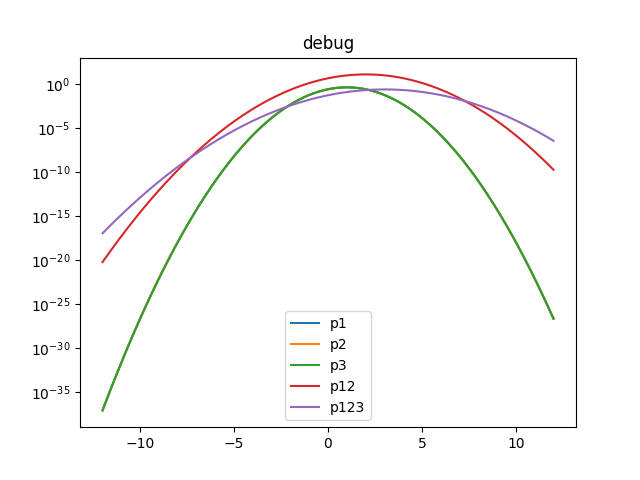

In [190]:
ll_convolved(x,mu1 = 1,sd1 = 1,mu2 = 1 ,sd2 = 1,mu3 = 1,sd3 = 1, moments= ['real','real','real'],dist = ['gauss','gauss','gauss'],verbose = True)